# Polymer Informatics Atlas

## Notebook 03 — Property-Specific Baseline Modelling

### Objective

Notebooks 01 and 02 established the chemical integrity of the polymer dataset and developed three modelling-ready structural representations:

1. **Interpretable polymer descriptors** — 36 chemically understandable features,
2. **Count Morgan radius-4 fingerprints** — 2048 local structural features with polymer connection points retained,
3. **Hybrid representation** — the combination of interpretable descriptors and Morgan features.

Notebook 03 evaluates how effectively these representations support prediction of five polymer properties:

- glass-transition temperature (Tg),
- fractional free volume (FFV),
- thermal conductivity (Tc),
- density,
- and radius of gyration (Rg).

Because target availability is highly sparse and asymmetric, each property is treated as an independent supervised-learning task.

The goals of this notebook are to:

1. construct one modelling dataset per target,
2. establish simple statistical and machine-learning baselines,
3. compare structural representations under identical validation procedures,
4. evaluate predictive accuracy using multiple complementary metrics,
5. examine residual behaviour and model stability,
6. identify strong baseline model–representation combinations for each property,
7. and generate reproducible outputs for subsequent chemistry-aware generalization analysis.

The purpose of this notebook is **baseline interpolation performance**.

Chemical novelty and out-of-domain generalization are addressed separately in Notebook 04.

## 1. Environment and Reproducibility

All modelling procedures use fixed random seeds and identical data partitions wherever model or representation comparisons are made.

The principal libraries are:

- **pandas** and **NumPy** for data handling,
- **scikit-learn** for preprocessing, regression, validation, and evaluation,
- **matplotlib** for diagnostic visualization.

Preprocessing operations that depend on the observed data are fitted within model pipelines so that information from validation or test observations cannot leak into model training.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Notebook 03 environment initialized.")

Notebook 03 environment initialized.


In [ ]:
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Scikit-learn modelling libraries loaded.")

Scikit-learn modelling libraries loaded.


## 2. Recovering the Modelling-Ready Representations

Notebook 02 exported the finalized feature matrices independently from the target-property metadata.

These outputs are loaded directly rather than regenerating fingerprints or descriptors.

The first task is to verify that:

- all feature matrices contain 7,973 polymer records,
- matrix row order remains aligned with the metadata table,
- the expected feature dimensions are preserved,
- and target counts reproduce the audited values from Notebook 01.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving polymer_atlas_notebook02_outputs.zip to polymer_atlas_notebook02_outputs.zip


In [ ]:
import zipfile

zip_filename = "polymer_atlas_notebook02_outputs.zip"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(
        "polymer_atlas_notebook02_outputs"
    )

print("Notebook 02 outputs extracted.")

Notebook 02 outputs extracted.


In [ ]:
input_dir = Path(
    "polymer_atlas_notebook02_outputs"
)

X_interpretable = np.load(
    input_dir / "X_interpretable.npy"
)

X_morgan = np.load(
    input_dir / "X_morgan_count_r4.npy"
)

X_hybrid = np.load(
    input_dir / "X_hybrid.npy"
)

metadata = pd.read_csv(
    input_dir / "polymer_model_metadata.csv"
)

interpretable_feature_names = (
    pd.read_csv(
        input_dir / "interpretable_feature_names.csv"
    )["feature"]
    .tolist()
)

print("Notebook 02 modelling outputs loaded.")

Notebook 02 modelling outputs loaded.


In [ ]:
target_columns = [
    "Tg",
    "FFV",
    "Tc",
    "Density",
    "Rg"
]

print("NOTEBOOK 03 ENTRY AUDIT")
print("=" * 70)

print(f"Metadata:       {metadata.shape}")
print(f"Interpretable:  {X_interpretable.shape}")
print(f"Morgan r4:      {X_morgan.shape}")
print(f"Hybrid:         {X_hybrid.shape}")

print("\nTARGET COUNTS")
print("-" * 70)

for target in target_columns:
    print(
        f"{target:8s}: "
        f"{metadata[target].notna().sum():,}"
    )

print("\nNUMERICAL INTEGRITY")
print("-" * 70)

print(
    "Interpretable NaN:",
    np.isnan(X_interpretable).sum()
)

print(
    "Morgan NaN:",
    np.isnan(X_morgan).sum()
)

print(
    "Hybrid NaN:",
    np.isnan(X_hybrid).sum()
)

NOTEBOOK 03 ENTRY AUDIT
Metadata:       (7973, 8)
Interpretable:  (7973, 36)
Morgan r4:      (7973, 2048)
Hybrid:         (7973, 2084)

TARGET COUNTS
----------------------------------------------------------------------
Tg      : 511
FFV     : 7,030
Tc      : 737
Density : 613
Rg      : 614

NUMERICAL INTEGRITY
----------------------------------------------------------------------
Interpretable NaN: 0
Morgan NaN: 0
Hybrid NaN: 0


In [ ]:
assert len(metadata) == X_interpretable.shape[0]
assert len(metadata) == X_morgan.shape[0]
assert len(metadata) == X_hybrid.shape[0]

assert X_interpretable.shape[1] == 36
assert X_morgan.shape[1] == 2048
assert X_hybrid.shape[1] == 2084

assert metadata["id"].is_unique

print(
    "All matrix dimensions and row counts are aligned."
)

All matrix dimensions and row counts are aligned.


## 3. Property-Specific Modelling Datasets

The five target properties have substantially different sample sizes and are not jointly available for most polymers.

A single complete-case modelling table would therefore discard the majority of the available information.

Instead, each target is treated as an independent supervised regression task. For a given property, all polymers with an available value for that property are retained, while polymers missing that target are excluded only from that specific task.

The structural feature matrices remain unchanged.

For fair comparison among representations, each target receives one fixed train/test partition. The same polymer indices are then used for the interpretable, Morgan, and hybrid representations.

Notebook 03 uses a conventional random interpolation-oriented evaluation. Chemistry-aware splitting designed to measure extrapolation to structurally distinct polymers is reserved for Notebook 04.

In [ ]:
# ============================================================
# Construct property-specific target datasets
# ============================================================

target_datasets = {}

for target in target_columns:

    available_mask = (
        metadata[target]
        .notna()
        .to_numpy()
    )

    indices = np.flatnonzero(
        available_mask
    )

    y = (
        metadata.loc[
            available_mask,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    target_datasets[target] = {
        "indices": indices,
        "y": y
    }


print("PROPERTY-SPECIFIC DATASETS")
print("=" * 70)

for target in target_columns:

    data = target_datasets[target]

    print(
        f"{target:8s}: "
        f"{len(data['y']):,} polymers"
    )

PROPERTY-SPECIFIC DATASETS
Tg      : 511 polymers
FFV     : 7,030 polymers
Tc      : 737 polymers
Density : 613 polymers
Rg      : 614 polymers


### 3.1 Fixed Baseline Holdout Strategy

Each property dataset is divided into a training set and an untouched test set.

An 80/20 split is used.

Because several polymer-property distributions are skewed or multimodal, approximate target-value quantiles are used to stratify the random partition. This reduces the chance that a small target dataset receives an unrepresentative test set containing disproportionately high or low values.

The quantile labels are used only for partition construction and are never provided to the predictive models.

All model and representation comparisons for a given target use exactly the same frozen partition.

The test set remains untouched during model comparison. Model selection and tuning are performed only within the training portion using cross-validation.

In [ ]:
# ============================================================
# Fixed property-specific train/test partitions
# ============================================================

TEST_SIZE = 0.20

target_splits = {}

for target in target_columns:

    indices = target_datasets[target]["indices"]
    y = target_datasets[target]["y"]

    # Approximate regression stratification using target quantiles
    n_bins = min(
        10,
        max(2, len(y) // 50)
    )

    stratification_bins = pd.qcut(
        y,
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    train_idx, test_idx = train_test_split(
        indices,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratification_bins
    )

    target_splits[target] = {
        "train_idx": train_idx,
        "test_idx": test_idx
    }


print("FROZEN PROPERTY-SPECIFIC SPLITS")
print("=" * 70)

for target in target_columns:

    train_idx = (
        target_splits[target]["train_idx"]
    )

    test_idx = (
        target_splits[target]["test_idx"]
    )

    print(
        f"{target:8s} | "
        f"train = {len(train_idx):5,d} | "
        f"test = {len(test_idx):5,d} | "
        f"total = {len(train_idx)+len(test_idx):5,d}"
    )

FROZEN PROPERTY-SPECIFIC SPLITS
Tg       | train =   408 | test =   103 | total =   511
FFV      | train = 5,624 | test = 1,406 | total = 7,030
Tc       | train =   589 | test =   148 | total =   737
Density  | train =   490 | test =   123 | total =   613
Rg       | train =   491 | test =   123 | total =   614


In [ ]:
# ============================================================
# Train/test target distribution audit
# ============================================================

split_audit_rows = []

for target in target_columns:

    train_idx = (
        target_splits[target]["train_idx"]
    )

    test_idx = (
        target_splits[target]["test_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy()
    )

    y_test = (
        metadata.loc[
            test_idx,
            target
        ]
        .to_numpy()
    )

    split_audit_rows.append({
        "Target": target,

        "Train_n":
            len(y_train),

        "Test_n":
            len(y_test),

        "Train_mean":
            np.mean(y_train),

        "Test_mean":
            np.mean(y_test),

        "Train_median":
            np.median(y_train),

        "Test_median":
            np.median(y_test),

        "Train_std":
            np.std(y_train),

        "Test_std":
            np.std(y_test),

        "Train_min":
            np.min(y_train),

        "Test_min":
            np.min(y_test),

        "Train_max":
            np.max(y_train),

        "Test_max":
            np.max(y_test)
    })


split_audit = (
    pd.DataFrame(
        split_audit_rows
    )
    .set_index("Target")
)

print("TRAIN/TEST TARGET DISTRIBUTION AUDIT")
print("=" * 70)

display(
    split_audit.round(4)
)

TRAIN/TEST TARGET DISTRIBUTION AUDIT


,Train_n,Test_n,Train_mean,Test_mean,Train_median,Test_median,Train_std,Test_std,Train_min,Test_min,Train_max,Test_max
Target,,,,,,,,,,,,
Tg,408,103,96.1841,97.5146,74.4486,73.8326,111.3566,110.1684,-148.0297,-81.3830,472.2500,423.6342
FFV,5624,1406,0.3672,0.3672,0.3643,0.3643,0.0295,0.0301,0.2270,0.2787,0.7771,0.7741
Tc,589,148,0.2566,0.2554,0.2360,0.2380,0.0897,0.0886,0.0465,0.0690,0.5240,0.4870
Density,490,123,0.9858,0.9844,0.9488,0.9465,0.1460,0.1463,0.7487,0.7571,1.8410,1.7323
Rg,491,123,16.4102,16.4580,15.0404,15.0640,4.5550,4.7985,9.9431,9.7284,34.4873,34.6729


In [ ]:
representation_matrices = {
    "Interpretable": X_interpretable,
    "Morgan_r4": X_morgan,
    "Hybrid": X_hybrid
}

print("AVAILABLE REPRESENTATIONS")
print("=" * 70)

for name, matrix in representation_matrices.items():

    print(
        f"{name:15s}: "
        f"{matrix.shape}"
    )

AVAILABLE REPRESENTATIONS
Interpretable  : (7973, 36)
Morgan_r4      : (7973, 2048)
Hybrid         : (7973, 2084)


### 3.2 Cross-Validation Within the Training Partition

The final test set is not used for model selection.

Model comparison is performed within the 80% training partition using five-fold shuffled cross-validation.

The same fold-generation procedure is applied to every model and representation.

This provides an estimate of model stability while preserving the final test subset for an independent evaluation after model selection.

In [ ]:
# ============================================================
# Cross-validation configuration
# ============================================================

N_CV_SPLITS = 5

cv = KFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("CROSS-VALIDATION CONFIGURATION")
print("=" * 70)

print(f"Number of folds: {N_CV_SPLITS}")
print("Shuffle:         True")
print(f"Random state:    {RANDOM_STATE}")
print("Applied to:      training partition only")

CROSS-VALIDATION CONFIGURATION
Number of folds: 5
Shuffle:         True
Random state:    42
Applied to:      training partition only


## 4. Evaluation Metrics and Statistical Baselines

Predictive performance is evaluated using three complementary regression metrics.

### Mean Absolute Error (MAE)

$$
\mathrm{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left|y_i-\hat{y}_i\right|
$$

MAE measures the average absolute prediction error in the original physical units of the property.

It is relatively robust to isolated large errors and therefore provides an intuitive measure of typical prediction accuracy.

### Root Mean Squared Error (RMSE)

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
}
$$

RMSE penalizes large prediction errors more strongly than MAE.

This is particularly relevant for polymer datasets containing broad property distributions or extreme observations.

### Coefficient of Determination ($R^2$)

$$
R^2
=
1-
\frac{
\sum_i \left(y_i-\hat{y}_i\right)^2
}{
\sum_i \left(y_i-\bar{y}\right)^2
}
$$

$R^2$ measures improvement relative to predicting the target mean.

- $R^2 = 1$ indicates perfect prediction.
- $R^2 = 0$ corresponds approximately to mean prediction.
- $R^2 < 0$ indicates performance worse than the mean-prediction reference.

Because the five polymer properties have different physical units and numerical scales, raw MAE or RMSE values should not be compared directly across different target properties.

Two non-chemical dummy models are evaluated before any structure-based model:

1. **Mean predictor** — predicts the training-fold mean for every validation polymer.
2. **Median predictor** — predicts the training-fold median for every validation polymer.

The mean predictor is the natural reference for squared-error and $R^2$ evaluation, whereas the median predictor provides a useful reference for absolute-error performance.

Any chemically informed machine-learning model should demonstrate meaningful improvement over these trivial baselines.

In [ ]:
# ============================================================
# Regression scoring framework
# ============================================================

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

print("REGRESSION METRICS")
print("=" * 70)
print("R²   : higher is better")
print("MAE  : lower is better")
print("RMSE : lower is better")

REGRESSION METRICS
R²   : higher is better
MAE  : lower is better
RMSE : lower is better


### 4.1 Dummy Regression Baselines

Dummy regressors intentionally ignore all polymer structural information.

Their purpose is not to produce useful scientific models, but to define the minimum level of predictive performance that a structure-based model must exceed.

The dummy models are evaluated using the same five-fold cross-validation procedure that will later be applied to the machine-learning models.

Only the frozen 80% training partition is used at this stage. The final test set remains untouched.

In [ ]:
# ============================================================
# Dummy baseline cross-validation
# ============================================================

dummy_results = []

dummy_strategies = {
    "Dummy_mean": DummyRegressor(
        strategy="mean"
    ),

    "Dummy_median": DummyRegressor(
        strategy="median"
    )
}


for target in target_columns:

    train_idx = (
        target_splits[target]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    # Dummy models do not use chemistry.
    # A single constant input column is sufficient.
    X_dummy = np.zeros(
        (len(y_train), 1),
        dtype=np.float32
    )

    for model_name, model in dummy_strategies.items():

        scores = cross_validate(
            model,
            X_dummy,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

        dummy_results.append({
            "Target": target,
            "Model": model_name,

            "CV_R2_mean":
                np.mean(
                    scores["test_R2"]
                ),

            "CV_R2_std":
                np.std(
                    scores["test_R2"]
                ),

            "CV_MAE_mean":
                -np.mean(
                    scores["test_MAE"]
                ),

            "CV_MAE_std":
                np.std(
                    -scores["test_MAE"]
                ),

            "CV_RMSE_mean":
                -np.mean(
                    scores["test_RMSE"]
                ),

            "CV_RMSE_std":
                np.std(
                    -scores["test_RMSE"]
                )
        })


dummy_results = pd.DataFrame(
    dummy_results
)

print("CROSS-VALIDATED DUMMY BASELINES")
print("=" * 80)

display(
    dummy_results.round(4)
)

CROSS-VALIDATED DUMMY BASELINES


,Target,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Tg,Dummy_mean,-0.0137,0.0191,88.3914,5.4337,111.3530,7.3160
1,Tg,Dummy_median,-0.0488,0.0347,86.6427,6.1468,113.3468,8.7552
2,FFV,Dummy_mean,-0.0001,0.0001,0.0210,0.0007,0.0294,0.0019
3,FFV,Dummy_median,-0.0106,0.0037,0.0208,0.0007,0.0296,0.0019
4,Tc,Dummy_mean,-0.0068,0.0053,0.0773,0.0034,0.0897,0.0047
5,Tc,Dummy_median,-0.0561,0.0429,0.0764,0.0044,0.0919,0.0062
6,Density,Dummy_mean,-0.0096,0.0108,0.1097,0.0073,0.1459,0.0102
7,Density,Dummy_median,-0.0728,0.0510,0.1048,0.0084,0.1503,0.0107
8,Rg,Dummy_mean,-0.0137,0.0183,3.9393,0.3513,4.5415,0.4969
9,Rg,Dummy_median,-0.0944,0.0829,3.8648,0.4446,4.7230,0.6188


In [ ]:
# ============================================================
# Target scales for interpreting error magnitudes
# ============================================================

target_scale_rows = []

for target in target_columns:

    train_idx = (
        target_splits[target]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    target_scale_rows.append({
        "Target": target,
        "Train_n": len(y_train),
        "Mean": np.mean(y_train),
        "Median": np.median(y_train),
        "Std": np.std(y_train),
        "Range": (
            np.max(y_train)
            - np.min(y_train)
        )
    })


target_scale_table = (
    pd.DataFrame(
        target_scale_rows
    )
    .set_index("Target")
)

print("TARGET SCALE REFERENCE")
print("=" * 70)

display(
    target_scale_table.round(4)
)

TARGET SCALE REFERENCE


,Train_n,Mean,Median,Std,Range
Target,,,,,
Tg,408,96.1841,74.4486,111.3566,620.2797
FFV,5624,0.3672,0.3643,0.0295,0.5501
Tc,589,0.2566,0.2360,0.0897,0.4775
Density,490,0.9858,0.9488,0.1460,1.0923
Rg,491,16.4102,15.0404,4.5550,24.5442


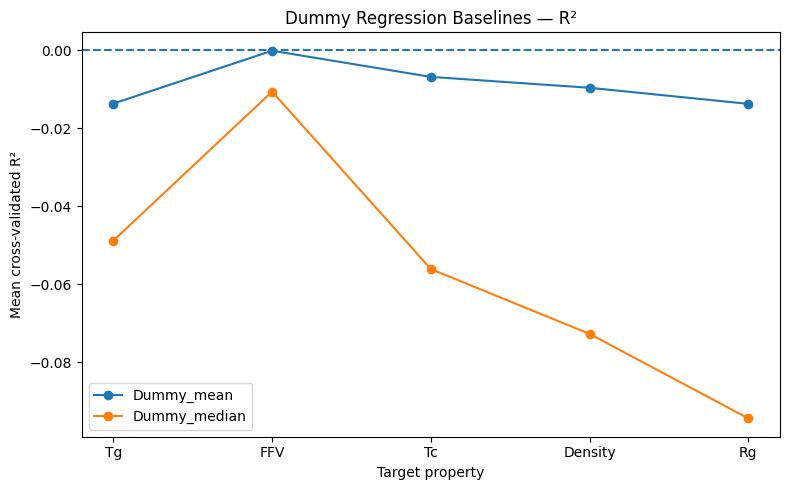

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in dummy_results["Model"].unique():

    subset = dummy_results.loc[
        dummy_results["Model"]
        == model_name
    ]

    plt.plot(
        subset["Target"],
        subset["CV_R2_mean"],
        marker="o",
        label=model_name
    )

plt.axhline(
    0,
    linestyle="--"
)

plt.ylabel("Mean cross-validated R²")
plt.xlabel("Target property")

plt.title(
    "Dummy Regression Baselines — R²"
)

plt.legend()
plt.tight_layout()
plt.show()

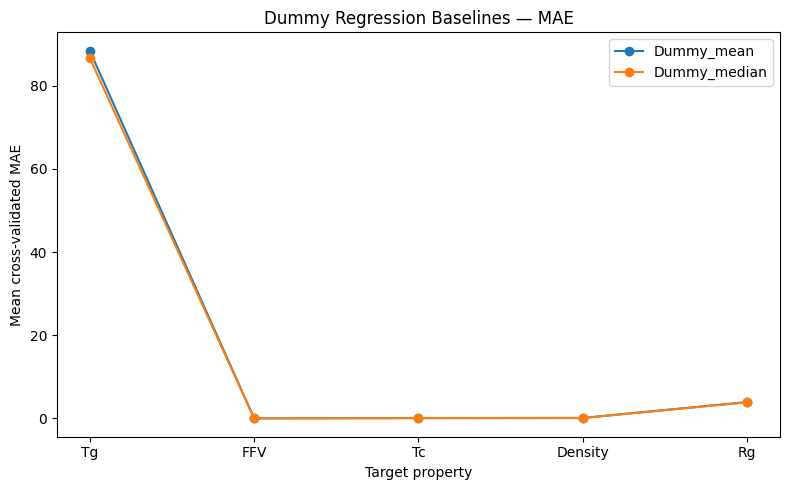

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in dummy_results["Model"].unique():

    subset = dummy_results.loc[
        dummy_results["Model"]
        == model_name
    ]

    plt.plot(
        subset["Target"],
        subset["CV_MAE_mean"],
        marker="o",
        label=model_name
    )

plt.ylabel(
    "Mean cross-validated MAE"
)

plt.xlabel(
    "Target property"
)

plt.title(
    "Dummy Regression Baselines — MAE"
)

plt.legend()
plt.tight_layout()
plt.show()

## 5. Regularized Linear Baseline — Ridge Regression

The first structure-based predictive model is Ridge regression.

Ordinary linear regression estimates a coefficient for every input feature. This becomes problematic for high-dimensional polymer representations because many descriptors and fingerprint features are correlated, and the Morgan and hybrid representations contain substantially more features than some target datasets contain labelled polymers.

Ridge regression addresses this problem by adding an L2 penalty to the ordinary least-squares objective:

$$
\underset{\beta}{\mathrm{minimize}}
\left[
\sum_{i=1}^{n}
\left(
y_i-\beta_0-\mathbf{x}_i^{T}\boldsymbol{\beta}
\right)^2
+
\alpha
\sum_{j=1}^{p}\beta_j^2
\right]
$$

The penalty discourages very large coefficients without forcing most coefficients exactly to zero.

This makes Ridge regression a useful baseline for determining how much of each polymer property can be represented as an approximately linear combination of the available structural features.

Three representation families are tested independently:

1. interpretable polymer descriptors,
2. radius-4 count Morgan fingerprints,
3. the hybrid representation.

Feature scaling is performed inside the modelling pipeline so that scaling parameters are estimated separately within each training fold. This prevents validation-fold information from leaking into preprocessing.

A fixed initial regularization strength of $\alpha=1$ is used for the baseline comparison. Hyperparameter tuning is deferred until model-family comparisons establish whether further optimization is justified.

In [ ]:
# ============================================================
# Ridge-regression baseline
# ============================================================

RIDGE_ALPHA = 1.0

ridge_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        Ridge(
            alpha=RIDGE_ALPHA
        )
    )
])

print("RIDGE BASELINE CONFIGURATION")
print("=" * 70)

print(f"Alpha:             {RIDGE_ALPHA}")
print("Feature scaling:   StandardScaler")
print("Scaling location:  inside CV pipeline")

RIDGE BASELINE CONFIGURATION
Alpha:             1.0
Feature scaling:   StandardScaler
Scaling location:  inside CV pipeline


In [ ]:
# ============================================================
# Ridge cross-validation
# ============================================================

ridge_results = []

for target in target_columns:

    train_idx = (
        target_splits[target]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    for representation_name, X_full in (
        representation_matrices.items()
    ):

        X_train = X_full[
            train_idx
        ]

        scores = cross_validate(
            ridge_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1
        )

        ridge_results.append({
            "Target":
                target,

            "Representation":
                representation_name,

            "Model":
                "Ridge",

            "CV_R2_mean":
                np.mean(
                    scores["test_R2"]
                ),

            "CV_R2_std":
                np.std(
                    scores["test_R2"]
                ),

            "CV_MAE_mean":
                -np.mean(
                    scores["test_MAE"]
                ),

            "CV_MAE_std":
                np.std(
                    -scores["test_MAE"]
                ),

            "CV_RMSE_mean":
                -np.mean(
                    scores["test_RMSE"]
                ),

            "CV_RMSE_std":
                np.std(
                    -scores["test_RMSE"]
                )
        })


ridge_results = pd.DataFrame(
    ridge_results
)

print("RIDGE CROSS-VALIDATION RESULTS")
print("=" * 90)

display(
    ridge_results.round(4)
)

RIDGE CROSS-VALIDATION RESULTS


,Target,Representation,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Tg,Interpretable,Ridge,0.5267,0.0403,59.2608,4.5965,76.0060,5.6739
1,Tg,Morgan_r4,Ridge,0.3619,0.0967,67.8758,4.3450,87.8960,6.0827
2,Tg,Hybrid,Ridge,0.4007,0.0913,66.1042,4.5937,85.1985,5.9999
3,FFV,Interpretable,Ridge,0.4735,0.0557,0.0141,0.0003,0.0213,0.0022
4,FFV,Morgan_r4,Ridge,0.3184,0.0629,0.0160,0.0006,0.0242,0.0009
5,FFV,Hybrid,Ridge,0.4926,0.0363,0.0136,0.0006,0.0209,0.0010
6,Tc,Interpretable,Ridge,0.6221,0.0542,0.0394,0.0023,0.0549,0.0060
7,Tc,Morgan_r4,Ridge,0.6426,0.0724,0.0379,0.0043,0.0533,0.0077
8,Tc,Hybrid,Ridge,0.5099,0.0390,0.0431,0.0034,0.0625,0.0041
9,Density,Interpretable,Ridge,0.8084,0.0598,0.0347,0.0022,0.0630,0.0110


In [ ]:
# ============================================================
# Ridge improvement over mean dummy baseline
# ============================================================

dummy_mean_reference = (
    dummy_results.loc[
        dummy_results["Model"]
        == "Dummy_mean"
    ]
    [
        [
            "Target",
            "CV_R2_mean",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
    .rename(columns={
        "CV_R2_mean":
            "Dummy_R2",

        "CV_MAE_mean":
            "Dummy_MAE",

        "CV_RMSE_mean":
            "Dummy_RMSE"
    })
)


ridge_vs_dummy = (
    ridge_results
    .merge(
        dummy_mean_reference,
        on="Target"
    )
)

ridge_vs_dummy[
    "R2_gain"
] = (
    ridge_vs_dummy["CV_R2_mean"]
    - ridge_vs_dummy["Dummy_R2"]
)

ridge_vs_dummy[
    "MAE_reduction_pct"
] = (
    (
        ridge_vs_dummy["Dummy_MAE"]
        - ridge_vs_dummy["CV_MAE_mean"]
    )
    /
    ridge_vs_dummy["Dummy_MAE"]
    * 100
)

ridge_vs_dummy[
    "RMSE_reduction_pct"
] = (
    (
        ridge_vs_dummy["Dummy_RMSE"]
        - ridge_vs_dummy["CV_RMSE_mean"]
    )
    /
    ridge_vs_dummy["Dummy_RMSE"]
    * 100
)


print("RIDGE IMPROVEMENT OVER MEAN DUMMY")
print("=" * 90)

display(
    ridge_vs_dummy[
        [
            "Target",
            "Representation",
            "CV_R2_mean",
            "R2_gain",
            "MAE_reduction_pct",
            "RMSE_reduction_pct"
        ]
    ]
    .round(3)
)

RIDGE IMPROVEMENT OVER MEAN DUMMY


,Target,Representation,CV_R2_mean,R2_gain,MAE_reduction_pct,RMSE_reduction_pct
0,Tg,Interpretable,0.527,0.540,32.956,31.743
1,Tg,Morgan_r4,0.362,0.376,23.210,21.066
2,Tg,Hybrid,0.401,0.414,25.214,23.488
3,FFV,Interpretable,0.473,0.474,32.756,27.429
4,FFV,Morgan_r4,0.318,0.318,23.505,17.732
5,FFV,Hybrid,0.493,0.493,34.925,28.931
6,Tc,Interpretable,0.622,0.629,49.005,38.756
7,Tc,Morgan_r4,0.643,0.649,50.909,40.506
8,Tc,Hybrid,0.510,0.517,44.248,30.278
9,Density,Interpretable,0.808,0.818,68.351,56.846


In [ ]:
# ============================================================
# Best Ridge representation by cross-validated R²
# ============================================================

best_ridge_by_target = (
    ridge_results
    .sort_values(
        "CV_R2_mean",
        ascending=False
    )
    .groupby(
        "Target",
        as_index=False
    )
    .first()
)

print("BEST RIDGE REPRESENTATION BY TARGET")
print("=" * 85)

display(
    best_ridge_by_target[
        [
            "Target",
            "Representation",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
    .round(4)
)

BEST RIDGE REPRESENTATION BY TARGET


,Target,Representation,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,Density,Interpretable,0.8084,0.0598,0.0347,0.0630
1,FFV,Hybrid,0.4926,0.0363,0.0136,0.0209
2,Rg,Morgan_r4,0.4014,0.0967,2.3293,3.4712
3,Tc,Morgan_r4,0.6426,0.0724,0.0379,0.0533
4,Tg,Interpretable,0.5267,0.0403,59.2608,76.0060


## 6. Nonlinear Baseline — Extra Trees Regression

The Ridge results demonstrate that substantial polymer-property signal can be recovered through linear combinations of the structural features.

However, polymer structure-property relationships are not necessarily linear.

For example, the effect of aromaticity may depend on ring density, heteroatom composition, repeat-unit size, or the simultaneous presence of particular functional groups. Such interactions cannot be represented naturally by a simple additive linear model.

Extra Trees regression is therefore introduced as the first nonlinear baseline.

Extra Trees constructs an ensemble of randomized decision trees. Each tree recursively partitions feature space and can represent:

- nonlinear descriptor-property relationships,
- threshold effects,
- interactions between structural variables,
- and heterogeneous regions of polymer chemical space.

Unlike Ridge regression, tree ensembles do not require feature standardization.

The model is deliberately evaluated with one fixed baseline configuration before any hyperparameter optimization. This preserves a fair distinction between model-family effects and parameter tuning.

In [ ]:
# ============================================================
# Extra Trees baseline configuration
# ============================================================

EXTRA_TREES_ESTIMATORS = 200

extra_trees_model = ExtraTreesRegressor(
    n_estimators=EXTRA_TREES_ESTIMATORS,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("EXTRA TREES BASELINE CONFIGURATION")
print("=" * 70)

print(
    f"Number of trees: "
    f"{EXTRA_TREES_ESTIMATORS}"
)

print("Random state:   42")
print("Feature scaling: not required")
print("Hyperparameter tuning: not yet performed")

EXTRA TREES BASELINE CONFIGURATION
Number of trees: 200
Random state:   42
Feature scaling: not required
Hyperparameter tuning: not yet performed


In [23]:
# ============================================================
# Extra Trees cross-validation
# ============================================================

extra_trees_results = []

for target in target_columns:

    print(f"Running Extra Trees — {target}")

    train_idx = (
        target_splits[target]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    for representation_name, X_full in (
        representation_matrices.items()
    ):

        print(
            f"  Representation: "
            f"{representation_name}"
        )

        X_train = X_full[
            train_idx
        ]

        scores = cross_validate(
            extra_trees_model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=1
        )

        extra_trees_results.append({
            "Target":
                target,

            "Representation":
                representation_name,

            "Model":
                "ExtraTrees",

            "CV_R2_mean":
                np.mean(
                    scores["test_R2"]
                ),

            "CV_R2_std":
                np.std(
                    scores["test_R2"]
                ),

            "CV_MAE_mean":
                -np.mean(
                    scores["test_MAE"]
                ),

            "CV_MAE_std":
                np.std(
                    -scores["test_MAE"]
                ),

            "CV_RMSE_mean":
                -np.mean(
                    scores["test_RMSE"]
                ),

            "CV_RMSE_std":
                np.std(
                    -scores["test_RMSE"]
                )
        })


extra_trees_results = pd.DataFrame(
    extra_trees_results
)

print("\nEXTRA TREES CROSS-VALIDATION RESULTS")
print("=" * 90)

display(
    extra_trees_results.round(4)
)

Running Extra Trees — Tg
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running Extra Trees — FFV
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running Extra Trees — Tc
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running Extra Trees — Density
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running Extra Trees — Rg
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid

EXTRA TREES CROSS-VALIDATION RESULTS


,Target,Representation,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Tg,Interpretable,ExtraTrees,0.5081,0.0383,60.2965,2.9700,77.4579,5.1892
1,Tg,Morgan_r4,ExtraTrees,0.5849,0.0569,55.5091,4.7008,71.0936,6.6080
2,Tg,Hybrid,ExtraTrees,0.6085,0.0435,53.3576,3.6143,69.0769,5.5652
3,FFV,Interpretable,ExtraTrees,0.6747,0.0519,0.0092,0.0002,0.0168,0.0024
4,FFV,Morgan_r4,ExtraTrees,0.7692,0.0669,0.0073,0.0003,0.0141,0.0028
5,FFV,Hybrid,ExtraTrees,0.7983,0.0737,0.0065,0.0002,0.0131,0.0031
6,Tc,Interpretable,ExtraTrees,0.6870,0.0716,0.0354,0.0045,0.0499,0.0078
7,Tc,Morgan_r4,ExtraTrees,0.7582,0.0358,0.0293,0.0025,0.0439,0.0050
8,Tc,Hybrid,ExtraTrees,0.7693,0.0569,0.0287,0.0034,0.0428,0.0072
9,Density,Interpretable,ExtraTrees,0.8079,0.0660,0.0356,0.0023,0.0627,0.0115


In [24]:
best_extra_trees_by_target = (
    extra_trees_results
    .sort_values(
        "CV_R2_mean",
        ascending=False
    )
    .groupby(
        "Target",
        as_index=False
    )
    .first()
)

print("BEST EXTRA TREES REPRESENTATION BY TARGET")
print("=" * 85)

display(
    best_extra_trees_by_target[
        [
            "Target",
            "Representation",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
    .round(4)
)

BEST EXTRA TREES REPRESENTATION BY TARGET


,Target,Representation,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,Density,Hybrid,0.8302,0.0793,0.0310,0.0584
1,FFV,Hybrid,0.7983,0.0737,0.0065,0.0131
2,Rg,Hybrid,0.6927,0.0782,1.6581,2.5057
3,Tc,Hybrid,0.7693,0.0569,0.0287,0.0428
4,Tg,Hybrid,0.6085,0.0435,53.3576,69.0769


In [25]:
ridge_vs_extra = (
    best_ridge_by_target[
        [
            "Target",
            "Representation",
            "CV_R2_mean",
            "CV_RMSE_mean"
        ]
    ]
    .rename(columns={
        "Representation":
            "Ridge_representation",

        "CV_R2_mean":
            "Ridge_R2",

        "CV_RMSE_mean":
            "Ridge_RMSE"
    })
    .merge(
        best_extra_trees_by_target[
            [
                "Target",
                "Representation",
                "CV_R2_mean",
                "CV_RMSE_mean"
            ]
        ]
        .rename(columns={
            "Representation":
                "ExtraTrees_representation",

            "CV_R2_mean":
                "ExtraTrees_R2",

            "CV_RMSE_mean":
                "ExtraTrees_RMSE"
        }),

        on="Target"
    )
)

ridge_vs_extra[
    "R2_gain_from_nonlinearity"
] = (
    ridge_vs_extra["ExtraTrees_R2"]
    - ridge_vs_extra["Ridge_R2"]
)

ridge_vs_extra[
    "RMSE_change_pct"
] = (
    (
        ridge_vs_extra["Ridge_RMSE"]
        - ridge_vs_extra["ExtraTrees_RMSE"]
    )
    /
    ridge_vs_extra["Ridge_RMSE"]
    * 100
)

print("LINEAR vs NONLINEAR BASELINE")
print("=" * 95)

display(
    ridge_vs_extra.round(4)
)

LINEAR vs NONLINEAR BASELINE


,Target,Ridge_representation,Ridge_R2,Ridge_RMSE,ExtraTrees_representation,ExtraTrees_R2,ExtraTrees_RMSE,R2_gain_from_nonlinearity,RMSE_change_pct
0,Density,Interpretable,0.8084,0.0630,Hybrid,0.8302,0.0584,0.0217,7.2010
1,FFV,Hybrid,0.4926,0.0209,Hybrid,0.7983,0.0131,0.3057,37.2798
2,Rg,Morgan_r4,0.4014,3.4712,Hybrid,0.6927,2.5057,0.2914,27.8154
3,Tc,Morgan_r4,0.6426,0.0533,Hybrid,0.7693,0.0428,0.1267,19.7927
4,Tg,Interpretable,0.5267,76.0060,Hybrid,0.6085,69.0769,0.0817,9.1164


## 7. Sequential Nonlinear Baseline — Histogram Gradient Boosting

Extra Trees regression demonstrated that nonlinear relationships and structural interactions substantially improve prediction for several polymer properties.

However, Extra Trees is an ensemble of independently randomized decision trees whose predictions are averaged.

Gradient boosting represents a different learning strategy.

Rather than constructing independent trees, boosting builds models sequentially. Each successive tree focuses on reducing errors remaining from the preceding ensemble.

Conceptually:

$$
F_m(\mathbf{x})
=
F_{m-1}(\mathbf{x})
+
\eta h_m(\mathbf{x})
$$

where:

- $F_{m-1}$ is the current ensemble,
- $h_m$ is the newly fitted tree,
- and $\eta$ is the learning rate.

Histogram Gradient Boosting is used as a computationally efficient implementation of this principle.

The model can capture:

- nonlinear structure-property relationships,
- descriptor interactions,
- threshold effects,
- and heterogeneous regions of polymer chemical space.

A fixed baseline configuration is evaluated before hyperparameter optimization.

Random Forest is not added at this stage because Extra Trees already provides a closely related bagged-tree baseline. Gradient boosting supplies a more methodologically distinct comparison.

In [26]:
# ============================================================
# Histogram Gradient Boosting baseline
# ============================================================

hist_gb_model = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

print("HISTOGRAM GRADIENT BOOSTING CONFIGURATION")
print("=" * 70)

print("Loss:                   squared error")
print("Maximum iterations:     100 (scikit-learn default)")
print("Learning rate:          0.1 (default)")
print("Maximum leaf nodes:     31 (default)")
print("Random state:           42")
print("Feature scaling:         not required")
print("Hyperparameter tuning:  not yet performed")

HISTOGRAM GRADIENT BOOSTING CONFIGURATION
Loss:                   squared error
Maximum iterations:     100 (scikit-learn default)
Learning rate:          0.1 (default)
Maximum leaf nodes:     31 (default)
Random state:           42
Feature scaling:         not required
Hyperparameter tuning:  not yet performed


In [27]:
# ============================================================
# Histogram Gradient Boosting cross-validation
# ============================================================

hist_gb_results = []

for target in target_columns:

    print(f"Running HistGradientBoosting — {target}")

    train_idx = target_splits[target]["train_idx"]

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    for representation_name, X_full in (
        representation_matrices.items()
    ):

        print(
            f"  Representation: "
            f"{representation_name}"
        )

        X_train = X_full[
            train_idx
        ]

        scores = cross_validate(
            hist_gb_model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=1
        )

        hist_gb_results.append({
            "Target":
                target,

            "Representation":
                representation_name,

            "Model":
                "HistGradientBoosting",

            "CV_R2_mean":
                np.mean(
                    scores["test_R2"]
                ),

            "CV_R2_std":
                np.std(
                    scores["test_R2"]
                ),

            "CV_MAE_mean":
                -np.mean(
                    scores["test_MAE"]
                ),

            "CV_MAE_std":
                np.std(
                    -scores["test_MAE"]
                ),

            "CV_RMSE_mean":
                -np.mean(
                    scores["test_RMSE"]
                ),

            "CV_RMSE_std":
                np.std(
                    -scores["test_RMSE"]
                )
        })


hist_gb_results = pd.DataFrame(
    hist_gb_results
)

print(
    "\nHISTOGRAM GRADIENT BOOSTING "
    "CROSS-VALIDATION RESULTS"
)
print("=" * 95)

display(
    hist_gb_results.round(4)
)

Running HistGradientBoosting — Tg
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running HistGradientBoosting — FFV
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running HistGradientBoosting — Tc
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running HistGradientBoosting — Density
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid
Running HistGradientBoosting — Rg
  Representation: Interpretable
  Representation: Morgan_r4
  Representation: Hybrid

HISTOGRAM GRADIENT BOOSTING CROSS-VALIDATION RESULTS


,Target,Representation,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std
0,Tg,Interpretable,HistGradientBoosting,0.5113,0.0746,60.4819,3.8202,76.8758,4.8336
1,Tg,Morgan_r4,HistGradientBoosting,0.5987,0.0295,53.1385,3.5827,69.9349,4.0029
2,Tg,Hybrid,HistGradientBoosting,0.5967,0.0369,54.0283,1.7716,70.0185,3.2094
3,FFV,Interpretable,HistGradientBoosting,0.6756,0.0723,0.0100,0.0003,0.0167,0.0028
4,FFV,Morgan_r4,HistGradientBoosting,0.7760,0.0693,0.0077,0.0003,0.0139,0.0030
5,FFV,Hybrid,HistGradientBoosting,0.8001,0.0767,0.0070,0.0003,0.0131,0.0033
6,Tc,Interpretable,HistGradientBoosting,0.6991,0.0757,0.0349,0.0046,0.0489,0.0083
7,Tc,Morgan_r4,HistGradientBoosting,0.7808,0.0518,0.0284,0.0033,0.0417,0.0070
8,Tc,Hybrid,HistGradientBoosting,0.7965,0.0470,0.0275,0.0029,0.0403,0.0066
9,Density,Interpretable,HistGradientBoosting,0.7704,0.0469,0.0380,0.0021,0.0692,0.0080


In [28]:
best_hist_gb_by_target = (
    hist_gb_results
    .sort_values(
        "CV_R2_mean",
        ascending=False
    )
    .groupby(
        "Target",
        as_index=False
    )
    .first()
)

print(
    "BEST HISTOGRAM GRADIENT BOOSTING "
    "REPRESENTATION BY TARGET"
)
print("=" * 90)

display(
    best_hist_gb_by_target[
        [
            "Target",
            "Representation",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
    .round(4)
)

BEST HISTOGRAM GRADIENT BOOSTING REPRESENTATION BY TARGET


,Target,Representation,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,Density,Hybrid,0.8070,0.0447,0.0329,0.0634
1,FFV,Hybrid,0.8001,0.0767,0.0070,0.0131
2,Rg,Morgan_r4,0.6935,0.0383,1.7213,2.5024
3,Tc,Hybrid,0.7965,0.0470,0.0275,0.0403
4,Tg,Morgan_r4,0.5987,0.0295,53.1385,69.9349


In [29]:
model_family_comparison = pd.concat([
    best_ridge_by_target[
        [
            "Target",
            "Representation",
            "Model",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ],

    best_extra_trees_by_target[
        [
            "Target",
            "Representation",
            "Model",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ],

    best_hist_gb_by_target[
        [
            "Target",
            "Representation",
            "Model",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
])

print("BEST RESULT FROM EACH MODEL FAMILY")
print("=" * 100)

display(
    model_family_comparison
    .sort_values(
        ["Target", "CV_R2_mean"],
        ascending=[True, False]
    )
    .round(4)
)

BEST RESULT FROM EACH MODEL FAMILY


,Target,Representation,Model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,Density,Hybrid,ExtraTrees,0.8302,0.0793,0.0310,0.0584
0,Density,Interpretable,Ridge,0.8084,0.0598,0.0347,0.0630
0,Density,Hybrid,HistGradientBoosting,0.8070,0.0447,0.0329,0.0634
1,FFV,Hybrid,HistGradientBoosting,0.8001,0.0767,0.0070,0.0131
1,FFV,Hybrid,ExtraTrees,0.7983,0.0737,0.0065,0.0131
1,FFV,Hybrid,Ridge,0.4926,0.0363,0.0136,0.0209
2,Rg,Morgan_r4,HistGradientBoosting,0.6935,0.0383,1.7213,2.5024
2,Rg,Hybrid,ExtraTrees,0.6927,0.0782,1.6581,2.5057
2,Rg,Morgan_r4,Ridge,0.4014,0.0967,2.3293,3.4712
3,Tc,Hybrid,HistGradientBoosting,0.7965,0.0470,0.0275,0.0403


In [30]:
current_champions = (
    model_family_comparison
    .sort_values(
        "CV_R2_mean",
        ascending=False
    )
    .groupby(
        "Target",
        as_index=False
    )
    .first()
)

print("CURRENT CROSS-VALIDATION CHAMPIONS")
print("=" * 90)

display(
    current_champions[
        [
            "Target",
            "Model",
            "Representation",
            "CV_R2_mean",
            "CV_R2_std",
            "CV_MAE_mean",
            "CV_RMSE_mean"
        ]
    ]
    .round(4)
)

CURRENT CROSS-VALIDATION CHAMPIONS


,Target,Model,Representation,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_RMSE_mean
0,Density,ExtraTrees,Hybrid,0.8302,0.0793,0.0310,0.0584
1,FFV,HistGradientBoosting,Hybrid,0.8001,0.0767,0.0070,0.0131
2,Rg,HistGradientBoosting,Morgan_r4,0.6935,0.0383,1.7213,2.5024
3,Tc,HistGradientBoosting,Hybrid,0.7965,0.0470,0.0275,0.0403
4,Tg,ExtraTrees,Hybrid,0.6085,0.0435,53.3576,69.0769


## 8. Targeted Hyperparameter Tuning

The baseline comparison already established which model–representation combinations are scientifically competitive for each property.

Rather than exhaustively tuning every near-tied candidate, one candidate is selected per target based on predictive performance, model stability, representation behaviour, and model complexity.

The selected candidates are:

- **Tg:** Extra Trees + Hybrid
- **FFV:** Histogram Gradient Boosting + Hybrid
- **Tc:** Histogram Gradient Boosting + Hybrid
- **Density:** Ridge + Interpretable descriptors
- **Rg:** Histogram Gradient Boosting + Morgan r4

Density is intentionally assigned to Ridge despite a slightly higher mean Extra Trees score because the 36-feature interpretable linear model achieved comparable cross-validated performance with substantially lower complexity.

Hyperparameter tuning is performed only within the frozen 80% development set.

A three-fold cross-validation procedure is used for this tuning stage. The earlier five-fold analysis already established baseline model stability; the purpose here is only to select reasonable hyperparameters for the shortlisted model.

The untouched 20% test set remains unavailable until all model-selection decisions are finalized.

In [36]:
# Remove any partial results from the interrupted exhaustive search

tuning_results = []
best_estimators = {}

print("Partial exhaustive-search results cleared.")

Partial exhaustive-search results cleared.


In [37]:
from sklearn.model_selection import GridSearchCV, KFold

tuning_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("TARGETED TUNING CV")
print("=" * 70)
print("Folds:        3")
print("Shuffle:      True")
print("Random state: 42")
print("Test set used: No")

TARGETED TUNING CV
Folds:        3
Shuffle:      True
Random state: 42
Test set used: No


In [38]:
selected_candidates = {
    "Tg": {
        "model": "ExtraTrees",
        "representation": "Hybrid"
    },

    "FFV": {
        "model": "HistGradientBoosting",
        "representation": "Hybrid"
    },

    "Tc": {
        "model": "HistGradientBoosting",
        "representation": "Hybrid"
    },

    "Density": {
        "model": "Ridge",
        "representation": "Interpretable"
    },

    "Rg": {
        "model": "HistGradientBoosting",
        "representation": "Morgan_r4"
    }
}

print("TARGETED MODEL SELECTION")
print("=" * 70)

for target, spec in selected_candidates.items():

    print(
        f"{target:8s} -> "
        f"{spec['model']:22s} "
        f"| {spec['representation']}"
    )

TARGETED MODEL SELECTION
Tg       -> ExtraTrees             | Hybrid
FFV      -> HistGradientBoosting   | Hybrid
Tc       -> HistGradientBoosting   | Hybrid
Density  -> Ridge                  | Interpretable
Rg       -> HistGradientBoosting   | Morgan_r4


In [39]:
ridge_targeted_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}


extra_trees_targeted_grid = {
    "n_estimators": [
        300
    ],

    "max_features": [
        1.0,
        0.5
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}


hist_gb_targeted_grid = {
    "learning_rate": [
        0.05,
        0.1
    ],

    "max_iter": [
        150,
        250
    ],

    "max_leaf_nodes": [
        15,
        31
    ],

    "l2_regularization": [
        1.0
    ]
}

print("Targeted parameter grids defined.")

Targeted parameter grids defined.


In [40]:
def build_targeted_model(model_name):

    if model_name == "Ridge":

        estimator = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Ridge()
            )
        ])

        param_grid = ridge_targeted_grid


    elif model_name == "ExtraTrees":

        estimator = ExtraTreesRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        param_grid = extra_trees_targeted_grid


    elif model_name == "HistGradientBoosting":

        estimator = HistGradientBoostingRegressor(
            random_state=RANDOM_STATE
        )

        param_grid = hist_gb_targeted_grid


    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return estimator, param_grid

In [41]:
targeted_tuning_results = []
best_estimators = {}

for target, spec in selected_candidates.items():

    model_name = spec["model"]
    representation_name = spec["representation"]

    print("\n" + "=" * 75)
    print(f"TUNING {target}")
    print("=" * 75)

    print(
        f"Model:          {model_name}"
    )

    print(
        f"Representation: {representation_name}"
    )

    train_idx = (
        target_splits[target]["train_idx"]
    )

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    X_full = (
        representation_matrices[
            representation_name
        ]
    )

    X_train = X_full[
        train_idx
    ]

    estimator, param_grid = (
        build_targeted_model(
            model_name
        )
    )

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="r2",
        cv=tuning_cv,
        n_jobs=1,
        refit=True,
        return_train_score=False
    )

    search.fit(
        X_train,
        y_train
    )

    key = (
        target,
        model_name,
        representation_name
    )

    best_estimators[key] = (
        search.best_estimator_
    )

    targeted_tuning_results.append({
        "Target":
            target,

        "Model":
            model_name,

        "Representation":
            representation_name,

        "Best_tuning_CV_R2":
            search.best_score_,

        "Best_params":
            search.best_params_
    })

    print(
        f"Best tuning CV R²: "
        f"{search.best_score_:.4f}"
    )

    print(
        f"Best parameters: "
        f"{search.best_params_}"
    )


TUNING Tg
Model:          ExtraTrees
Representation: Hybrid
Best tuning CV R²: 0.6239
Best parameters: {'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 300}

TUNING FFV
Model:          HistGradientBoosting
Representation: Hybrid
Best tuning CV R²: 0.7987
Best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_iter': 250, 'max_leaf_nodes': 31}

TUNING Tc
Model:          HistGradientBoosting
Representation: Hybrid
Best tuning CV R²: 0.7951
Best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_iter': 150, 'max_leaf_nodes': 31}

TUNING Density
Model:          Ridge
Representation: Interpretable
Best tuning CV R²: 0.8202
Best parameters: {'model__alpha': 10.0}

TUNING Rg
Model:          HistGradientBoosting
Representation: Morgan_r4
Best tuning CV R²: 0.6756
Best parameters: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_iter': 150, 'max_leaf_nodes': 15}


In [42]:
targeted_tuning_results = pd.DataFrame(
    targeted_tuning_results
)

print("\nTARGETED TUNING RESULTS")
print("=" * 100)

display(
    targeted_tuning_results
)


TARGETED TUNING RESULTS


,Target,Model,Representation,Best_tuning_CV_R2,Best_params
0,Tg,ExtraTrees,Hybrid,0.623933,"{'max_features': 1.0, 'min_samples_leaf': 4, '..."
1,FFV,HistGradientBoosting,Hybrid,0.798689,"{'l2_regularization': 1.0, 'learning_rate': 0...."
2,Tc,HistGradientBoosting,Hybrid,0.795077,"{'l2_regularization': 1.0, 'learning_rate': 0...."
3,Density,Ridge,Interpretable,0.820236,{'model__alpha': 10.0}
4,Rg,HistGradientBoosting,Morgan_r4,0.675596,"{'l2_regularization': 1.0, 'learning_rate': 0...."


In [43]:
baseline_selected_rows = []

for target, spec in selected_candidates.items():

    model_name = spec["model"]
    representation_name = spec["representation"]

    if model_name == "Ridge":
        source = ridge_results

    elif model_name == "ExtraTrees":
        source = extra_trees_results

    elif model_name == "HistGradientBoosting":
        source = hist_gb_results

    row = source.loc[
        (source["Target"] == target)
        &
        (
            source["Representation"]
            == representation_name
        )
    ].iloc[0]

    baseline_selected_rows.append({
        "Target":
            target,

        "Baseline_5fold_R2":
            row["CV_R2_mean"],

        "Baseline_5fold_R2_std":
            row["CV_R2_std"]
    })


baseline_selected = pd.DataFrame(
    baseline_selected_rows
)

tuning_context = (
    targeted_tuning_results
    .merge(
        baseline_selected,
        on="Target"
    )
)

print("BASELINE AND TUNING CONTEXT")
print("=" * 100)

display(
    tuning_context[
        [
            "Target",
            "Model",
            "Representation",
            "Baseline_5fold_R2",
            "Baseline_5fold_R2_std",
            "Best_tuning_CV_R2",
            "Best_params"
        ]
    ]
)

BASELINE AND TUNING CONTEXT


,Target,Model,Representation,Baseline_5fold_R2,Baseline_5fold_R2_std,Best_tuning_CV_R2,Best_params
0,Tg,ExtraTrees,Hybrid,0.608465,0.043534,0.623933,"{'max_features': 1.0, 'min_samples_leaf': 4, '..."
1,FFV,HistGradientBoosting,Hybrid,0.800128,0.076728,0.798689,"{'l2_regularization': 1.0, 'learning_rate': 0...."
2,Tc,HistGradientBoosting,Hybrid,0.796493,0.046951,0.795077,"{'l2_regularization': 1.0, 'learning_rate': 0...."
3,Density,Ridge,Interpretable,0.808439,0.059836,0.820236,{'model__alpha': 10.0}
4,Rg,HistGradientBoosting,Morgan_r4,0.693540,0.038341,0.675596,"{'l2_regularization': 1.0, 'learning_rate': 0...."


## 9. Final Evaluation on the Untouched Holdout Set

Model families, molecular representations, and hyperparameters have now been selected exclusively using the 80% development partition.

The workflow used:

- five-fold cross-validation for initial model and representation screening;
- three-fold cross-validation for targeted hyperparameter tuning;
- no use of the holdout data during model selection.

The selected configurations are therefore frozen before final evaluation.

Each final model is fitted using the complete 80% development partition and evaluated once on its corresponding untouched 20% holdout set.

The resulting R², MAE, and RMSE values represent the final random-split generalization performance for Notebook 03.

No model family, representation, or hyperparameter will be modified in response to the holdout results.

## 10. Final Evaluation on the Untouched Holdout Set

Model families, representations, and hyperparameters have now been selected exclusively using the 80% development partition.

No information from the 20% holdout set has been used during model selection or hyperparameter tuning.

The selected configurations are therefore frozen before final evaluation.

Each model is fitted using the complete 80% development partition and evaluated once on its corresponding untouched 20% test partition.

The holdout results provide the final random-split generalization estimates for Notebook 03.

No model, representation, or hyperparameter will be changed in response to the holdout results.

In [45]:
# ============================================================
# Frozen final model configurations
# ============================================================

final_model_specs = {
    "Tg": {
        "representation": "Hybrid",
        "model": ExtraTreesRegressor(
            n_estimators=300,
            max_features=1.0,
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    },

    "FFV": {
        "representation": "Hybrid",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    },

    "Tc": {
        "representation": "Hybrid",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    },

    "Density": {
        "representation": "Interpretable",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0))
        ])
    },

    "Rg": {
        "representation": "Morgan_r4",
        "model": HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
    }
}

print("Final model configurations frozen.")

Final model configurations frozen.


In [46]:
# ============================================================
# FINAL HOLDOUT EVALUATION
# ============================================================

final_test_results = []
final_predictions = {}

for target, spec in final_model_specs.items():

    representation_name = spec["representation"]
    model = spec["model"]

    train_idx = target_splits[target]["train_idx"]
    test_idx = target_splits[target]["test_idx"]

    X_full = representation_matrices[
        representation_name
    ]

    X_train = X_full[train_idx]
    X_test = X_full[test_idx]

    y_train = (
        metadata.loc[
            train_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    y_test = (
        metadata.loc[
            test_idx,
            target
        ]
        .to_numpy(dtype=np.float64)
    )

    # Fit using the complete 80% development partition
    model.fit(
        X_train,
        y_train
    )

    # Evaluate once on untouched 20% holdout
    y_pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    final_predictions[target] = {
        "test_idx": test_idx,
        "y_true": y_test,
        "y_pred": y_pred
    }

    final_test_results.append({
        "Target": target,
        "Model": type(model).__name__,
        "Representation": representation_name,
        "Train_n": len(train_idx),
        "Test_n": len(test_idx),
        "Test_R2": r2,
        "Test_MAE": mae,
        "Test_RMSE": rmse
    })

    print(
        f"{target:8s} | "
        f"R² = {r2:.4f} | "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f}"
    )


final_test_results = pd.DataFrame(
    final_test_results
)

print("\nFINAL UNTOUCHED HOLDOUT RESULTS")
print("=" * 100)

display(
    final_test_results.round(4)
)

Tg       | R² = 0.6077 | MAE = 54.7176 | RMSE = 69.0041
FFV      | R² = 0.7036 | MAE = 0.0067 | RMSE = 0.0164
Tc       | R² = 0.8246 | MAE = 0.0249 | RMSE = 0.0371
Density  | R² = 0.9201 | MAE = 0.0275 | RMSE = 0.0413
Rg       | R² = 0.7026 | MAE = 1.6985 | RMSE = 2.6170

FINAL UNTOUCHED HOLDOUT RESULTS


,Target,Model,Representation,Train_n,Test_n,Test_R2,Test_MAE,Test_RMSE
0,Tg,ExtraTreesRegressor,Hybrid,408,103,0.6077,54.7176,69.0041
1,FFV,HistGradientBoostingRegressor,Hybrid,5624,1406,0.7036,0.0067,0.0164
2,Tc,HistGradientBoostingRegressor,Hybrid,589,148,0.8246,0.0249,0.0371
3,Density,Pipeline,Interpretable,490,123,0.9201,0.0275,0.0413
4,Rg,HistGradientBoostingRegressor,Morgan_r4,491,123,0.7026,1.6985,2.6170


## 10. Holdout Error and Residual Analysis

Aggregate performance metrics summarize predictive accuracy but do not reveal how prediction errors are distributed across the property range.

The final holdout predictions are therefore examined using parity plots, residual distributions, and absolute-error diagnostics.

For each target:

- observed values are compared directly with predicted values;
- residuals are defined as:

$$
e_i = y_i - \hat{y}_i
$$

where $y_i$ is the observed value and $\hat{y}_i$ is the model prediction;

- absolute errors are examined to identify poorly predicted holdout polymers;
- residual behavior is inspected across the predicted property range.

Because the holdout set has already been opened, these diagnostics are strictly interpretive.

No subsequent model selection or hyperparameter modification will be performed using these observations.

In [47]:
holdout_prediction_tables = {}

for target in target_columns:

    pred_info = final_predictions[target]

    test_idx = pred_info["test_idx"]
    y_true = pred_info["y_true"]
    y_pred = pred_info["y_pred"]

    residual = y_true - y_pred
    absolute_error = np.abs(residual)

    prediction_table = pd.DataFrame({
        "row_index": test_idx,
        "id": metadata.loc[
            test_idx,
            "id"
        ].to_numpy(),

        "SMILES": metadata.loc[
            test_idx,
            "SMILES"
        ].to_numpy(),

        "Observed": y_true,
        "Predicted": y_pred,
        "Residual": residual,
        "Absolute_Error": absolute_error
    })

    holdout_prediction_tables[target] = (
        prediction_table
    )


print("Holdout prediction tables created.")

for target, table in (
    holdout_prediction_tables.items()
):

    print(
        f"{target:8s}: "
        f"{table.shape[0]} holdout predictions"
    )

Holdout prediction tables created.
Tg      : 103 holdout predictions
FFV     : 1406 holdout predictions
Tc      : 148 holdout predictions
Density : 123 holdout predictions
Rg      : 123 holdout predictions


In [48]:
residual_summary = []

for target, table in (
    holdout_prediction_tables.items()
):

    residual = table["Residual"]
    abs_error = table["Absolute_Error"]

    residual_summary.append({
        "Target":
            target,

        "Mean_residual":
            residual.mean(),

        "Median_residual":
            residual.median(),

        "Residual_std":
            residual.std(),

        "Median_absolute_error":
            abs_error.median(),

        "P90_absolute_error":
            abs_error.quantile(0.90),

        "P95_absolute_error":
            abs_error.quantile(0.95),

        "Max_absolute_error":
            abs_error.max()
    })


residual_summary = pd.DataFrame(
    residual_summary
)

print("HOLDOUT RESIDUAL SUMMARY")
print("=" * 100)

display(
    residual_summary.round(4)
)

HOLDOUT RESIDUAL SUMMARY


,Target,Mean_residual,Median_residual,Residual_std,Median_absolute_error,P90_absolute_error,P95_absolute_error,Max_absolute_error
0,Tg,1.3115,-8.5601,69.3290,42.6745,114.6750,117.9970,215.7982
1,FFV,-0.0001,-0.0005,0.0164,0.0041,0.0138,0.0194,0.4171
2,Tc,-0.0018,-0.0002,0.0372,0.0173,0.0561,0.0829,0.1831
3,Density,0.0064,0.0052,0.0410,0.0195,0.0571,0.0682,0.2538
4,Rg,-0.0406,-0.1759,2.6274,1.0946,3.5656,4.9914,15.7016


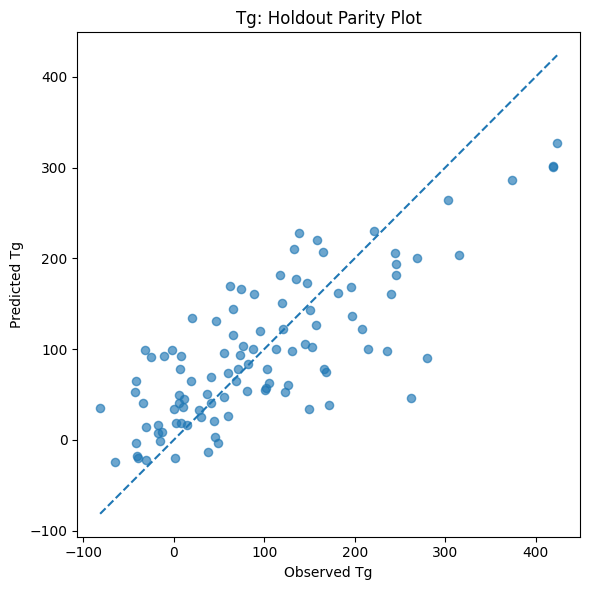

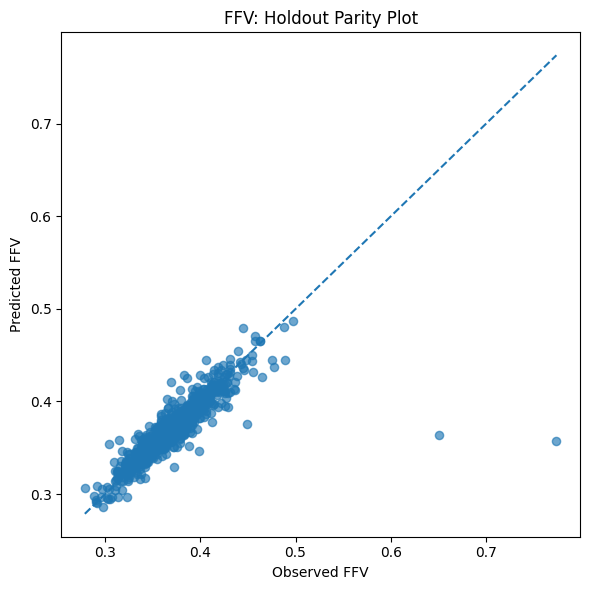

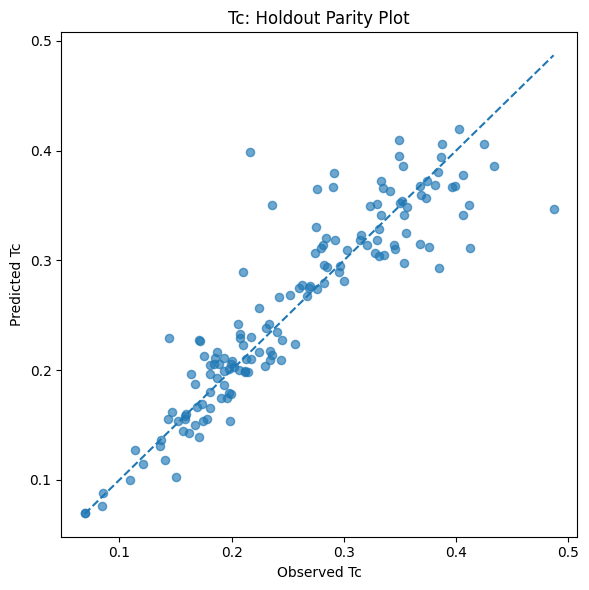

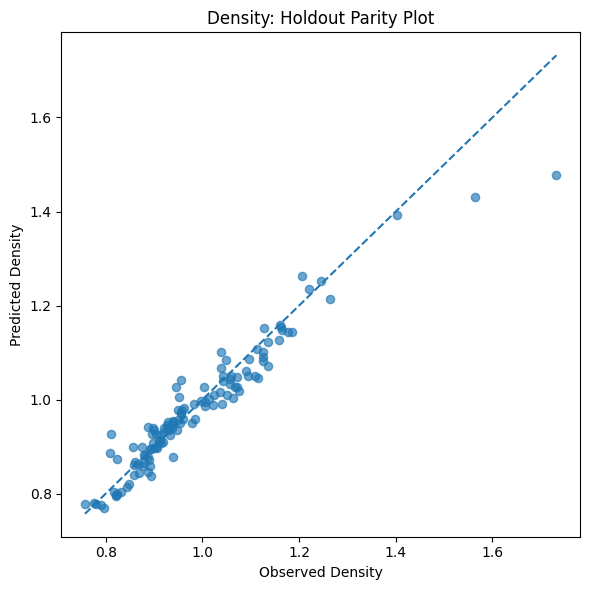

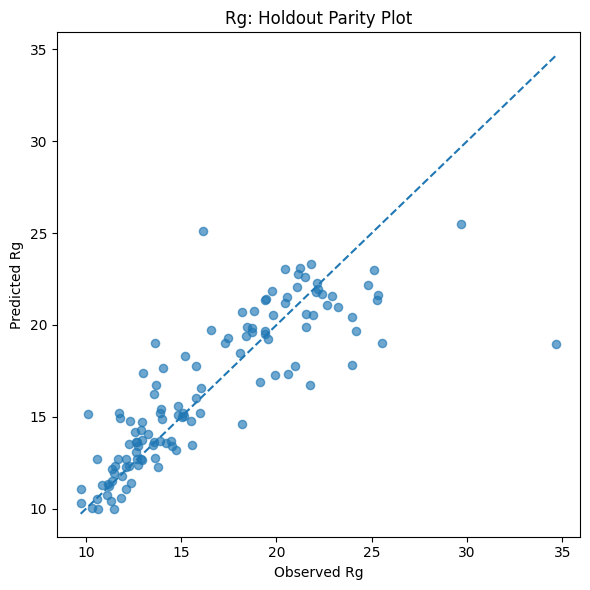

In [49]:
import matplotlib.pyplot as plt

for target, table in (
    holdout_prediction_tables.items()
):

    observed = table["Observed"]
    predicted = table["Predicted"]

    plot_min = min(
        observed.min(),
        predicted.min()
    )

    plot_max = max(
        observed.max(),
        predicted.max()
    )

    plt.figure(figsize=(6, 6))

    plt.scatter(
        observed,
        predicted,
        alpha=0.65,
        s=35
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--"
    )

    plt.xlabel(
        f"Observed {target}"
    )

    plt.ylabel(
        f"Predicted {target}"
    )

    plt.title(
        f"{target}: Holdout Parity Plot"
    )

    plt.tight_layout()
    plt.show()

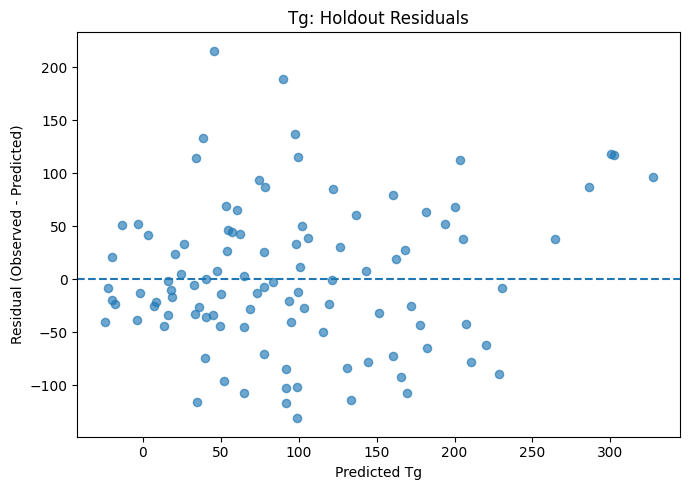

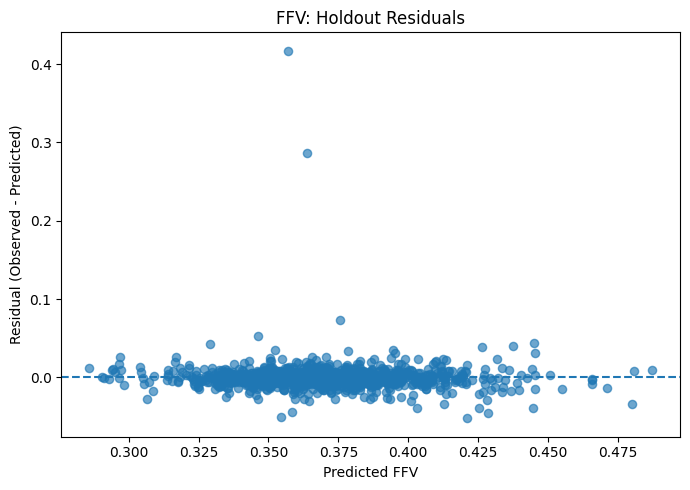

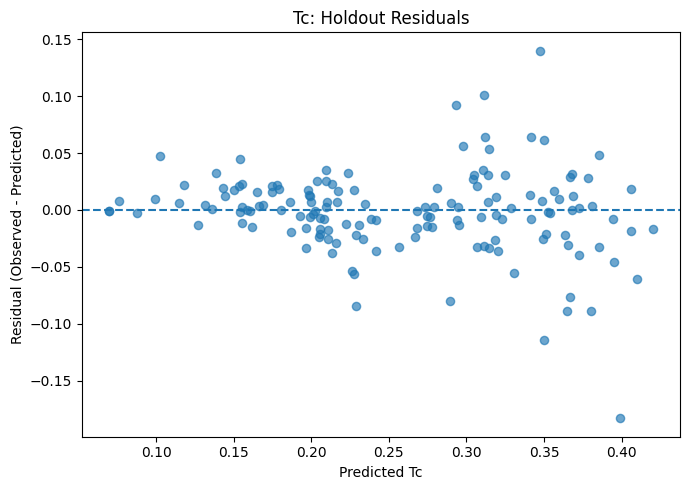

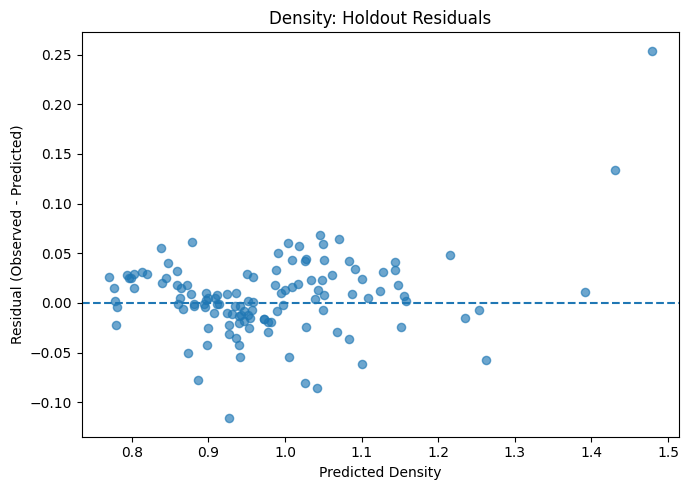

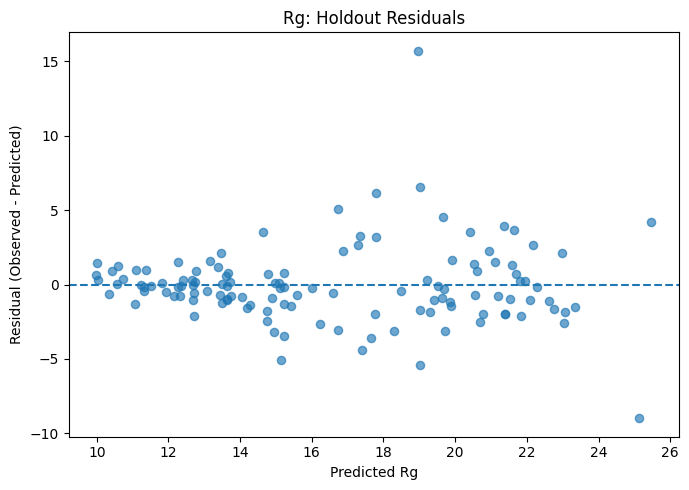

In [50]:
for target, table in (
    holdout_prediction_tables.items()
):

    plt.figure(figsize=(7, 5))

    plt.scatter(
        table["Predicted"],
        table["Residual"],
        alpha=0.65,
        s=35
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        f"Predicted {target}"
    )

    plt.ylabel(
        "Residual (Observed - Predicted)"
    )

    plt.title(
        f"{target}: Holdout Residuals"
    )

    plt.tight_layout()
    plt.show()

In [51]:
for target, table in (
    holdout_prediction_tables.items()
):

    worst = (
        table
        .sort_values(
            "Absolute_Error",
            ascending=False
        )
        .head(10)
    )

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"{target} — 10 LARGEST "
        f"HOLDOUT ERRORS"
    )

    print(
        "=" * 100
    )

    display(
        worst[
            [
                "id",
                "Observed",
                "Predicted",
                "Residual",
                "Absolute_Error",
                "SMILES"
            ]
        ]
        .round(4)
    )


Tg — 10 LARGEST HOLDOUT ERRORS


,id,Observed,Predicted,Residual,Absolute_Error,SMILES
100,2147435020,261.6624,45.8641,215.7982,215.7982,*C=C(*)c1ccccc1C
59,1559096063,279.4452,90.1163,189.3290,189.3290,*c1ccc(*)n1C(C)C(=O)OC
85,1766008027,235.3708,97.9274,137.4434,137.4434,*Nc1c([2H])c([2H])c(*)c([2H])c1[2H]
10,1932564704,172.0634,38.8471,133.2163,133.2163,*=C=C=C(COC(=O)NCC)C(=*)COC(=O)NCC
97,457518738,-32.2579,98.9882,-131.2461,131.2461,*CCN(CCCC(=O)Nc1ccc(N=Nc2ccccc2)cc1)CCOC(=O)Nc...
101,219039564,418.6900,300.6310,118.0590,118.0590,*c1ccc2c(c1)SC1=Nc3cc(-c4ccc5c(c4)N=C4Sc6cc(*)...
83,270662526,419.5781,302.1388,117.4393,117.4393,*c1ccc(Sc2ccc(-c3nc(-c4cccc(-c5nnc(-c6ccccc6)c...
24,274614510,-24.8244,91.6326,-116.4570,116.4570,*OC(CC(*)=O)C(C)C
2,1003531277,-81.3830,34.6915,-116.0745,116.0745,*CC(*)C(=O)N1CC[N+](C)(CCCCCCCCCCCC)CC1
76,1889222328,214.7483,99.6742,115.0742,115.0742,*Nc1cc(SCCC#N)c(NC(=O)c2ccc(C(*)=O)cc2)cc1SCCC#N



FFV — 10 LARGEST HOLDOUT ERRORS


,id,Observed,Predicted,Residual,Absolute_Error,SMILES
686,806978622,0.7741,0.3570,0.4171,0.4171,*CC(*)O[N+](=O)[O-]
807,713393124,0.6509,0.3639,0.2870,0.2870,*CC(*)C(=O)N1CC[NH+](CC)CC1
359,1330844840,0.4489,0.3757,0.0732,0.0732,*CC(COCOCC(C)([N+](=O)[O-])[N+](=O)[O-])O*
449,1949953064,0.3687,0.4211,-0.0524,0.0524,*c1cccc(*)c1
257,753005996,0.3986,0.3463,0.0522,0.0522,*N=P(*)(NCC)NCC
276,1396173463,0.3036,0.3546,-0.0510,0.0510,*NC(=O)O[C@@H]1/C=C\C=C/[C@H](C)[C@@H](/C(C)=C...
528,391755316,0.3826,0.4284,-0.0458,0.0458,*C=CC1CC(*)C2C3CCC(C3)C12
18,1542132482,0.3141,0.3585,-0.0444,0.0444,*Nc1ccccc1-c1c(N)c(N)c(-c2ccccc2N)c(-c2ccccc2N...
457,689573357,0.4892,0.4448,0.0443,0.0443,*CC(*)c1ccc([Si](O[Si](C)(C)C)(O[Si](C)(C)C)O[...
1046,1695838608,0.3719,0.3292,0.0426,0.0426,*O[Si](C)(C)c1cc(OCCO)c([Si](*)(C)C)cc1OCCO



Tc — 10 LARGEST HOLDOUT ERRORS


,id,Observed,Predicted,Residual,Absolute_Error,SMILES
25,472726378,0.2160,0.3991,-0.1831,0.1831,*c1ccc2c(c1)C(CCCCCC)(CCCCCC)c1cc(-c3cc(CCCCCC...
108,2986007,0.4870,0.3471,0.1399,0.1399,*c1ccc(-c2ccc3c(c2)C(CCCCCCC#N)(CCCCCCC#N)c2cc...
71,774116157,0.2360,0.3501,-0.1141,0.1141,*c1ccc(-c2ccc3c(c2)C(CCCCCCBr)(CCCCCCBr)c2cc(*...
103,1528389333,0.4125,0.3111,0.1014,0.1014,*CCCCCCCCCCNC(=O)CCCCCCCCC(=O)NCCCCCCCCCCNC(=O...
10,203328995,0.3852,0.2934,0.0918,0.0918,*CCCCCCCCCCOCCCCCCCCCCOCCCCCO*
42,1150209468,0.2910,0.3801,-0.0891,0.0891,*c1ccc2c(c1)C(CCCCCC)(CCCCCC)c1cc(-c3cc(OCCCCC...
48,974171598,0.2760,0.3647,-0.0887,0.0887,*CCCCCCCCCCCCCCCCCCCCOC(=O)CCCCCCCCC(=O)O*
12,1619024957,0.1443,0.2290,-0.0846,0.0846,*CC1(*)CCCCC1
27,268805413,0.2100,0.2897,-0.0797,0.0797,*c1nc(C)nc(N(CCCCCCN(*)c2ccccc2)c2ccccc2)n1
39,1097591808,0.2900,0.3668,-0.0768,0.0768,*c1ccc(-c2cc(-c3ccc(OCCCCCC)cc3)cc(-c3ccc(-c4c...



Density — 10 LARGEST HOLDOUT ERRORS


,id,Observed,Predicted,Residual,Absolute_Error,SMILES
14,700931497,1.7323,1.4785,0.2538,0.2538,*ON(C(F)(F)F)C(F)(F)C(*)(F)F
43,1403885669,1.5647,1.4313,0.1334,0.1334,*C(F)(F)C(F)(F)C1(F)C(*)(F)OC(F)(F)C1(F)F
95,1515877635,0.8101,0.9262,-0.1161,0.1161,*CC(*)(C)C(=O)OCC(C)(C)C
5,442933041,0.9560,1.0419,-0.0859,0.0859,*/C=C/c1ccc(*)c(-c2cc(OCCC(C)C)c(OCCC(C)C)cc2-...
7,1372197295,0.9459,1.0260,-0.0800,0.0800,*Oc1c(C)cc(*)cc1C
86,1514643124,0.8085,0.8862,-0.0776,0.0776,*CC(*)(C)c1ccc(C(C)C)cc1
0,1515872647,1.1144,1.0457,0.0687,0.0687,*CC(*)C(=O)N1CCOCC1
67,434774652,1.1347,1.0708,0.0639,0.0639,*CC(*)C(=O)Oc1ccc(C#N)cc1
63,881173814,1.0391,1.1005,-0.0614,0.0614,*C1C(=O)N(c2ccccc2)C(=O)C1*
106,1774773315,0.9396,0.8782,0.0613,0.0613,*C1C=CC(*)C1



Rg — 10 LARGEST HOLDOUT ERRORS


,id,Observed,Predicted,Residual,Absolute_Error,SMILES
70,933916766,34.6729,18.9713,15.7016,15.7016,*/C=C/*
122,346660576,16.1434,25.1282,-8.9848,8.9848,*c1ccc(-c2ccc(C3(*)CCCCC3)cc2)cc1
30,1677600893,25.5411,19.0079,6.5332,6.5332,*Oc1ccc(C(C)(C)c2ccc(OC(=O)c3ccc(C(*)=O)cc3)cc...
90,354906741,23.9773,17.8027,6.1746,6.1746,*C(=O)c1ccc2c(c1)C(=O)N(c1ccc(Oc3ccc(C(=O)c4cc...
9,943955993,13.6156,19.0108,-5.3952,5.3952,*c1cc(*)c(O)c(/C=N/c2ccc(Cl)cc2)c1
36,1653502391,10.1000,15.1530,-5.0530,5.0530,*CC(*)(CC(=O)OCCCc1ccccc1)C(=O)OCCCc1ccccc1
50,64606581,21.7779,16.7352,5.0427,5.0427,*CC1CCC(*)C1
45,2103408562,24.1792,19.6499,4.5293,4.5293,*SC(*)(F)F
1,1619024957,12.9942,17.4014,-4.4072,4.4072,*CC1(*)CCCCC1
32,471964961,29.7009,25.4753,4.2256,4.2256,*c1ccc(Cc2ccc(-n3c(=O)c4cc5c(=O)n(*)c(=O)c5cc4...


### 10.6 Error Concentration

Large aggregate errors can arise either from broadly distributed prediction uncertainty or from a small number of extreme failures.

To distinguish these behaviours, the contribution of the largest holdout errors to total squared error and total absolute error is quantified.

A strong concentration of error in only a few observations would indicate that aggregate RMSE or R² is disproportionately influenced by rare difficult polymers rather than uniformly poor prediction.

In [52]:
error_concentration_rows = []

for target, table in holdout_prediction_tables.items():

    temp = table.copy()

    temp["Squared_Error"] = (
        temp["Residual"] ** 2
    )

    temp = temp.sort_values(
        "Squared_Error",
        ascending=False
    )

    total_sse = (
        temp["Squared_Error"].sum()
    )

    total_absolute_error = (
        temp["Absolute_Error"].sum()
    )

    row = {
        "Target": target,
        "n_test": len(temp)
    }

    for k in [1, 5, 10]:

        k_eff = min(
            k,
            len(temp)
        )

        top = temp.head(
            k_eff
        )

        row[
            f"Top{k}_SSE_share_pct"
        ] = (
            100
            * top["Squared_Error"].sum()
            / total_sse
        )

        row[
            f"Top{k}_AE_share_pct"
        ] = (
            100
            * top["Absolute_Error"].sum()
            / total_absolute_error
        )

    error_concentration_rows.append(
        row
    )


error_concentration = pd.DataFrame(
    error_concentration_rows
)

print("HOLDOUT ERROR CONCENTRATION")
print("=" * 100)

display(
    error_concentration.round(2)
)

HOLDOUT ERROR CONCENTRATION


,Target,n_test,Top1_SSE_share_pct,Top1_AE_share_pct,Top5_SSE_share_pct,Top5_AE_share_pct,Top10_SSE_share_pct,Top10_AE_share_pct
0,Tg,103,9.50,3.83,27.79,14.32,41.65,24.67
1,FFV,1406,45.98,4.46,70.63,9.43,73.40,11.87
2,Tc,148,16.44,4.97,41.59,17.11,58.86,28.49
3,Density,123,30.66,7.50,52.09,19.78,62.72,29.62
4,Rg,123,29.27,7.52,51.90,20.48,64.81,31.61


### 10.7 Error Across the Observed Property Range

The holdout observations are divided into property-value quantiles to test whether predictive error changes systematically across the response range.

This analysis evaluates whether models perform similarly throughout the observed domain or whether extreme low- and high-value regions are intrinsically more difficult.

The analysis is diagnostic only and is not used to modify the frozen models.

In [53]:
property_bin_results = []

for target, table in holdout_prediction_tables.items():

    temp = table.copy()

    temp["Observed_bin"] = pd.qcut(
        temp["Observed"],
        q=5,
        duplicates="drop"
    )

    for bin_label, group in (
        temp.groupby(
            "Observed_bin",
            observed=True
        )
    ):

        rmse = np.sqrt(
            np.mean(
                group["Residual"] ** 2
            )
        )

        property_bin_results.append({
            "Target":
                target,

            "Observed_bin":
                str(bin_label),

            "n":
                len(group),

            "Observed_mean":
                group["Observed"].mean(),

            "MAE":
                group[
                    "Absolute_Error"
                ].mean(),

            "RMSE":
                rmse,

            "Mean_residual":
                group[
                    "Residual"
                ].mean()
        })


property_bin_results = pd.DataFrame(
    property_bin_results
)

print(
    "ERROR BY OBSERVED PROPERTY QUINTILE"
)
print("=" * 110)

display(
    property_bin_results.round(4)
)

ERROR BY OBSERVED PROPERTY QUINTILE


,Target,Observed_bin,n,Observed_mean,MAE,RMSE,Mean_residual
0,Tg,"(-81.384, 3.364]",21,-27.5340,56.4145,69.5362,-54.3792
1,Tg,"(3.364, 53.952]",20,25.4403,38.5648,49.0449,-21.0749
2,Tg,"(53.952, 106.561]",21,77.7417,36.9318,46.7940,-14.9812
3,Tg,"(106.561, 170.541]",20,140.7974,51.9893,60.1283,8.2858
4,Tg,"(170.541, 423.634]",21,269.7565,88.7884,102.9334,87.9732
5,FFV,"(0.278, 0.346]",282,0.3328,0.0067,0.0098,-0.0034
6,FFV,"(0.346, 0.359]",281,0.3530,0.0042,0.0060,-0.0016
7,FFV,"(0.359, 0.37]",281,0.3643,0.0050,0.0077,-0.0009
8,FFV,"(0.37, 0.386]",281,0.3771,0.0061,0.0087,0.0005
9,FFV,"(0.386, 0.774]",281,0.4090,0.0113,0.0328,0.0050


## 11. Notebook 03 Conclusions

Property-specific baseline modelling established a controlled random-split reference point for the Polymer Informatics Atlas.

Three complementary model families were evaluated:

- regularized linear regression (Ridge);
- randomized nonlinear tree ensembles (Extra Trees);
- sequential nonlinear boosting (Histogram Gradient Boosting).

Three representation spaces were compared:

- interpretable polymer descriptors;
- count-based Morgan radius-4 fingerprints;
- a hybrid representation combining both spaces.

All model and representation screening was performed using five-fold cross-validation within a frozen 80% development partition. Hyperparameters for the selected candidates were subsequently optimized using three-fold cross-validation without accessing the holdout data.

The final model configurations were frozen before evaluation on the untouched 20% holdout set.

### Final random-split performance

| Property | Final model | Representation | Holdout R² | Holdout MAE | Holdout RMSE |
|---|---|---|---:|---:|---:|
| Tg | Extra Trees | Hybrid | 0.6077 | 54.7176 | 69.0041 |
| FFV | Histogram Gradient Boosting | Hybrid | 0.7036 | 0.0067 | 0.0164 |
| Tc | Histogram Gradient Boosting | Hybrid | 0.8246 | 0.0249 | 0.0371 |
| Density | Ridge | Interpretable | 0.9201 | 0.0275 | 0.0413 |
| Rg | Histogram Gradient Boosting | Morgan r4 | 0.7026 | 1.6985 | 2.6170 |

The preferred representation was property dependent.

Density was particularly well described by a low-dimensional interpretable representation and regularized linear model, indicating that broad compositional and structural descriptors capture a large fraction of its random-split variation.

Tg benefited from combining global descriptors with local structural information, while FFV and Tc showed substantial gains from nonlinear modelling of the hybrid representation.

Rg depended more strongly on the detailed Morgan representation, supporting the earlier observation that local and topological structural environments contain information not fully represented by the global descriptor set.

Residual analysis showed that high aggregate predictive performance does not imply uniform reliability throughout property space.

Several properties exhibited regression toward the central response range, particularly Tg, for which low values were systematically overpredicted and high values systematically underpredicted.

FFV exhibited especially strong error concentration: a single holdout observation contributed approximately 46% of the total squared error, while the ten largest errors contributed approximately 73%. This indicates that the majority of FFV predictions are substantially more accurate than the aggregate RMSE alone suggests, but rare extreme polymers remain difficult.

Density and Rg also showed substantial concentration of squared error in a small number of observations, and upper-property regions were generally more difficult than central regions.

These findings define the principal limitation of the current notebook:

**random splitting primarily measures interpolation within a chemically overlapping dataset and does not establish performance on structurally novel polymers.**

Notebook 04 therefore evaluates chemistry-aware generalization, asking how predictive accuracy changes as test polymers become increasingly dissimilar from the available training chemistry.

## 12. Export Notebook 03 Results

The principal model-selection, tuning, holdout-prediction, and diagnostic outputs are exported for downstream notebooks and reproducibility.

These files preserve the results of Notebook 03 without requiring the computationally expensive model-selection workflow to be rerun.

In [54]:
from pathlib import Path
import json

notebook03_output_dir = Path(
    "polymer_atlas_notebook03_outputs"
)

notebook03_output_dir.mkdir(
    exist_ok=True
)

print(
    f"Output directory: "
    f"{notebook03_output_dir}"
)

Output directory: polymer_atlas_notebook03_outputs


In [55]:
# ============================================================
# Export summary tables
# ============================================================

dummy_results.to_csv(
    notebook03_output_dir
    / "dummy_baseline_cv_results.csv",
    index=False
)

ridge_results.to_csv(
    notebook03_output_dir
    / "ridge_cv_results.csv",
    index=False
)

extra_trees_results.to_csv(
    notebook03_output_dir
    / "extra_trees_cv_results.csv",
    index=False
)

hist_gb_results.to_csv(
    notebook03_output_dir
    / "hist_gradient_boosting_cv_results.csv",
    index=False
)

targeted_tuning_results.to_csv(
    notebook03_output_dir
    / "targeted_tuning_results.csv",
    index=False
)

final_test_results.to_csv(
    notebook03_output_dir
    / "final_holdout_results.csv",
    index=False
)

residual_summary.to_csv(
    notebook03_output_dir
    / "holdout_residual_summary.csv",
    index=False
)

error_concentration.to_csv(
    notebook03_output_dir
    / "holdout_error_concentration.csv",
    index=False
)

property_bin_results.to_csv(
    notebook03_output_dir
    / "holdout_property_quintile_errors.csv",
    index=False
)

print("Summary tables exported.")

Summary tables exported.


In [56]:
# ============================================================
# Export holdout predictions
# ============================================================

for target, table in (
    holdout_prediction_tables.items()
):

    table.to_csv(
        notebook03_output_dir
        / f"{target}_holdout_predictions.csv",
        index=False
    )

print(
    "Per-target holdout predictions exported."
)

Per-target holdout predictions exported.


In [57]:
# ============================================================
# Export frozen train/test indices
# ============================================================

split_rows = []

for target in target_columns:

    train_idx = target_splits[
        target
    ]["train_idx"]

    test_idx = target_splits[
        target
    ]["test_idx"]

    for idx in train_idx:

        split_rows.append({
            "Target": target,
            "row_index": int(idx),
            "Partition": "train"
        })

    for idx in test_idx:

        split_rows.append({
            "Target": target,
            "row_index": int(idx),
            "Partition": "test"
        })


frozen_split_table = pd.DataFrame(
    split_rows
)

frozen_split_table.to_csv(
    notebook03_output_dir
    / "frozen_target_splits.csv",
    index=False
)

print("Frozen target splits exported.")

Frozen target splits exported.


In [58]:
# ============================================================
# Export final modelling configuration
# ============================================================

notebook03_config = {
    "random_state": 42,

    "development_fraction": 0.80,
    "holdout_fraction": 0.20,

    "baseline_cv_folds": 5,
    "tuning_cv_folds": 3,

    "selection_metric": "R2",

    "final_models": {

        "Tg": {
            "model": "ExtraTreesRegressor",
            "representation": "Hybrid",
            "n_estimators": 300,
            "max_features": 1.0,
            "min_samples_leaf": 4
        },

        "FFV": {
            "model":
                "HistGradientBoostingRegressor",
            "representation": "Hybrid",
            "learning_rate": 0.1,
            "max_iter": 250,
            "max_leaf_nodes": 31,
            "l2_regularization": 1.0
        },

        "Tc": {
            "model":
                "HistGradientBoostingRegressor",
            "representation": "Hybrid",
            "learning_rate": 0.1,
            "max_iter": 250,
            "max_leaf_nodes": 31,
            "l2_regularization": 1.0
        },

        "Density": {
            "model": "Ridge",
            "representation": "Interpretable",
            "alpha": 10.0,
            "standard_scaling": True
        },

        "Rg": {
            "model":
                "HistGradientBoostingRegressor",
            "representation": "Morgan_r4",
            "learning_rate": 0.05,
            "max_iter": 250,
            "max_leaf_nodes": 15,
            "l2_regularization": 1.0
        }
    },

    "holdout_policy":
        "Holdout evaluated once after model, representation, "
        "and hyperparameter selection were frozen."
}


with open(
    notebook03_output_dir
    / "notebook03_model_config.json",
    "w"
) as f:

    json.dump(
        notebook03_config,
        f,
        indent=2
    )


print("Model configuration exported.")

Model configuration exported.


In [59]:
import shutil

archive_path = shutil.make_archive(
    "polymer_atlas_notebook03_outputs",
    "zip",
    root_dir=notebook03_output_dir
)

print(
    f"Notebook 03 archive created:\n"
    f"{archive_path}"
)

Notebook 03 archive created:
/content/polymer_atlas_notebook03_outputs.zip


In [60]:
print("NOTEBOOK 03 EXPORT AUDIT")
print("=" * 80)

exported_files = sorted(
    notebook03_output_dir.iterdir()
)

for path in exported_files:
    print(
        f"{path.name:45s} "
        f"{path.stat().st_size / 1024:.2f} KB"
    )

print(
    f"\nTotal exported files: "
    f"{len(exported_files)}"
)

print(
    "\nNotebook 03 scientific workflow complete."
)

NOTEBOOK 03 EXPORT AUDIT
Density_holdout_predictions.csv               13.42 KB
FFV_holdout_predictions.csv                   206.82 KB
Rg_holdout_predictions.csv                    14.29 KB
Tc_holdout_predictions.csv                    17.15 KB
Tg_holdout_predictions.csv                    13.38 KB
dummy_baseline_cv_results.csv                 1.43 KB
extra_trees_cv_results.csv                    2.21 KB
final_holdout_results.csv                     0.58 KB
frozen_target_splits.csv                      136.66 KB
hist_gradient_boosting_cv_results.csv         2.36 KB
holdout_error_concentration.csv               0.70 KB
holdout_property_quintile_errors.csv          2.58 KB
holdout_residual_summary.csv                  0.84 KB
notebook03_model_config.json                  1.22 KB
ridge_cv_results.csv                          2.13 KB
targeted_tuning_results.csv                   0.65 KB

Total exported files: 16

Notebook 03 scientific workflow complete.
